# Exploratory Data Analysis

In [2]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import matplotlib as mpl
import matplotlib.colors as mcolors
import os
import random
from PIL import Image
import cv2


# Raw data

In [3]:
# get the number of files in the Eyes_detection and Face_detection directories
eyes_folder = "../Eyes_detection/"
face_folder = "../Face_detection/"

_, _, eyes_files = next(os.walk(eyes_folder))
_, _, face_files = next(os.walk(face_folder))

print("Eyes files: ", len(eyes_files))
print("Face files: ", len(face_files))

print(len(eyes_files) + len(face_files))

Eyes files:  1087
Face files:  2222
3309


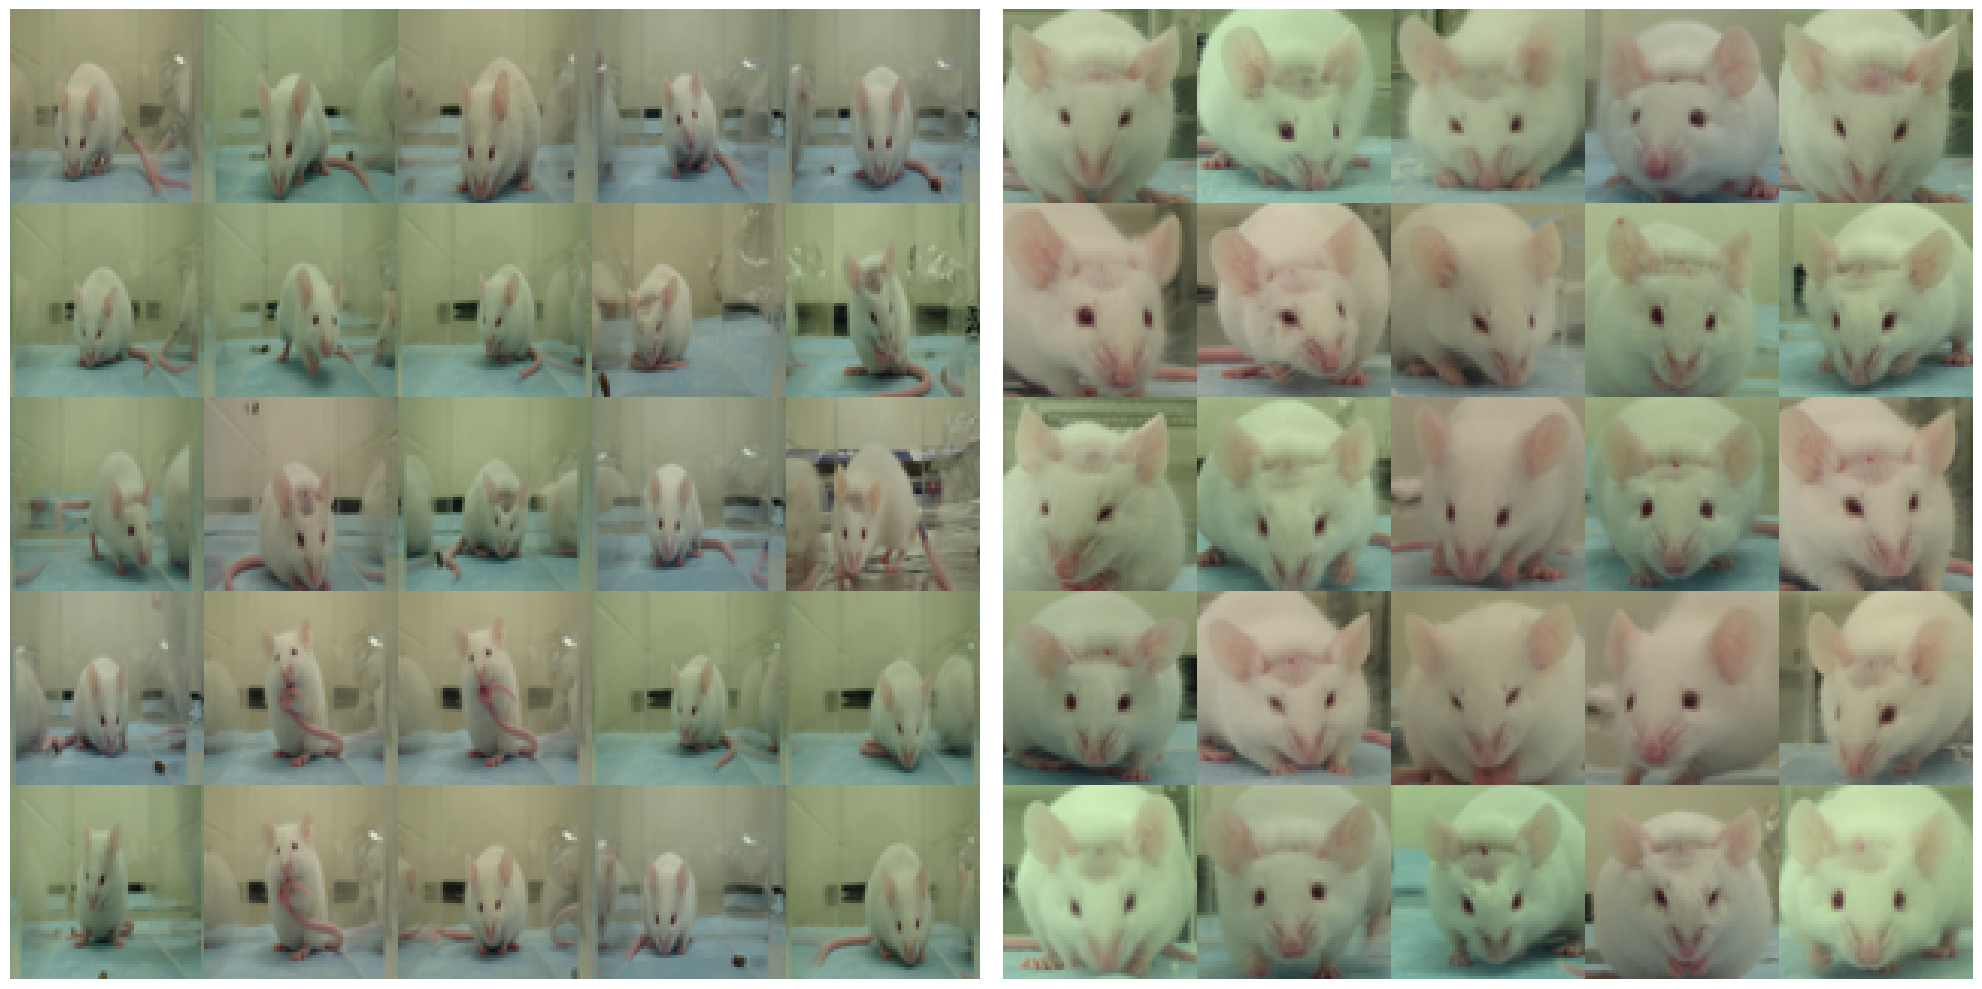

In [4]:
# create a sample of random images for each dataset (each presented in a grid of 10x10)
def create_image_grid(image_paths, folder, grid_size=5, thumb_size=(64, 64)):
    grid_img = Image.new('RGB', (thumb_size[0]*grid_size, thumb_size[1]*grid_size))
    
    for i, filename in enumerate(image_paths[:grid_size*grid_size]):
        try:
            path = os.path.join(folder, filename)
            img = Image.open(path).convert("RGB")
            img = img.resize(thumb_size)
            x = (i % grid_size) * thumb_size[0]
            y = (i // grid_size) * thumb_size[1]
            grid_img.paste(img, (x, y))
        except Exception as e:
            print(f"Error processing {filename}: {e}")
    return grid_img

sample_faces = random.sample(face_files, min(100, len(face_files)))
sample_eyes = random.sample(eyes_files, min(100, len(eyes_files)))

face_grid = create_image_grid(sample_faces, face_folder)
eyes_grid = create_image_grid(sample_eyes, eyes_folder)

# display both grids side by side
plt.figure(figsize=(20, 10))

plt.subplot(1, 2, 1)
#plt.title("Face Detection - 100 sample images")
plt.imshow(face_grid)
plt.axis('off')

plt.subplot(1, 2, 2)
#plt.title("Eyes Detection - 100 sample images")
plt.imshow(eyes_grid)
plt.axis('off')

plt.tight_layout()
plt.show()


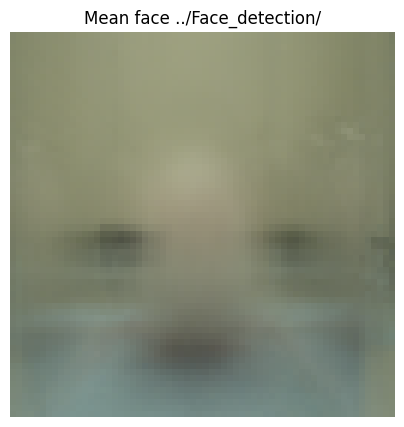

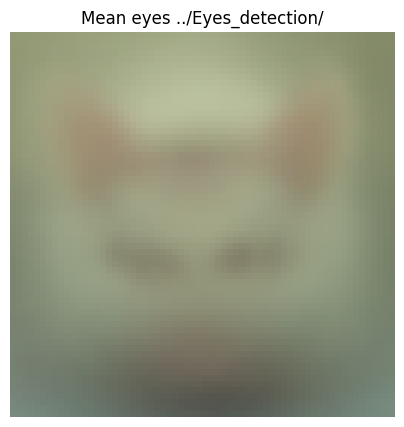

In [5]:
def compute_mean_image(folder, file_list, size=(64,64)):
    total = np.zeros((size[1], size[0], 3), np.float64)

    for file in file_list:
        path = os.path.join(folder, file)
        img = cv2.imread(path)  # BGR format
        if img is None:
            continue
        img = cv2.resize(img, size)
        total += img[..., ::-1]  # BGR --> RGB
    mean = (total / len(file_list)).astype(np.uint8)
    return Image.fromarray(mean)

mean_face_img = compute_mean_image(face_folder, face_files)
plt.figure(figsize=(5, 5))
plt.title(f"Mean face {face_folder}")
plt.imshow(mean_face_img)
plt.axis('off')
plt.show()

mean_eyes_img = compute_mean_image(eyes_folder, eyes_files)
plt.figure(figsize=(5, 5))
plt.title(f"Mean eyes {eyes_folder}")
plt.imshow(mean_eyes_img)
plt.axis('off')
plt.show()

# Labels

In [6]:
def count_animal_numbers(path):
    with open(path, "r", encoding="utf-8") as f:
        data = json.load(f)

    records = []
    for img_name, entries in data.items():
        for entry in entries:
            records.append({
                "Image": img_name,
                "AnimalNumber": entry.get("AnimalNumber")
            })

    df = pd.DataFrame(records)
    counts = df["AnimalNumber"].value_counts().sort_index()

    norm = mcolors.Normalize(vmin=counts.min(), vmax=counts.max())
    colormap = mpl.colormaps["Reds"]
    colors = [colormap(norm(value)) for value in counts.values]

    plt.figure(figsize=(6,4))
    counts.plot(kind="bar", color=colors)
    plt.xlabel("AnimalNumber")
    plt.ylabel("count")
    plt.title(f"AnimalNumber distribution in {path}")
    plt.tight_layout()
    plt.show()

    return counts

In [7]:
# grimmace score distribution
def count_grimmace_scores(path):
    with open(path, "r", encoding="utf-8") as f:
        data = json.load(f)

    records = []
    for img_name, entries in data.items():
        for entry in entries:
            records.append({
                "Image": img_name,
                "GrimmaceScore": entry.get("GrimaceScale")
            })
    
    df = pd.DataFrame(records)
    counts = df["GrimmaceScore"].value_counts().sort_index()
    
    norm = mcolors.Normalize(vmin=counts.min(), vmax=counts.max())
    colormap = mpl.colormaps["Reds"]
    colors = [colormap(norm(value)) for value in counts.values]

    plt.figure(figsize=(6,4))
    counts.plot(kind="bar", color=colors)
    plt.xlabel("GrimmaceScore")
    plt.ylabel("count")
    plt.title(f"GrimmaceScore distribution")
    plt.tight_layout()
    plt.show()

    return counts
            

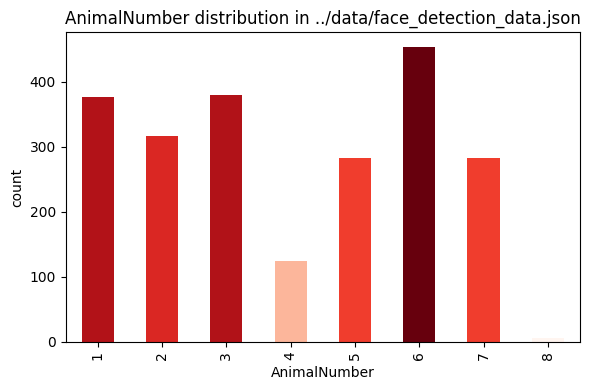

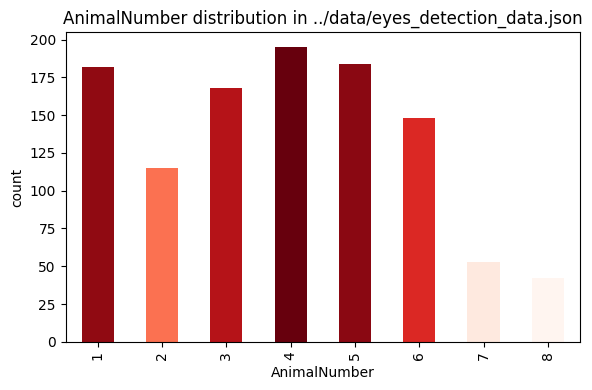

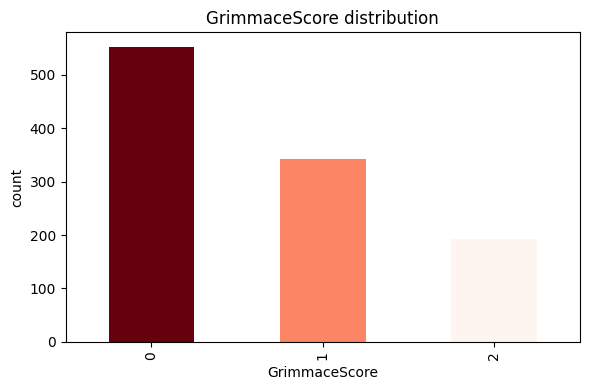

GrimmaceScore
0    552
1    342
2    193
Name: count, dtype: int64

In [9]:
count_animal_numbers("../data/face_detection_data.json")
count_animal_numbers("../data/eyes_detection_data.json")
count_grimmace_scores("../data/eyes_detection_data.json")

Face dataset: minimum count = 6, maximum count = 453
Eyes dataset: minimum count = 42, maximum count = 195
Combined dataset: minimum count = 48, maximum count = 601


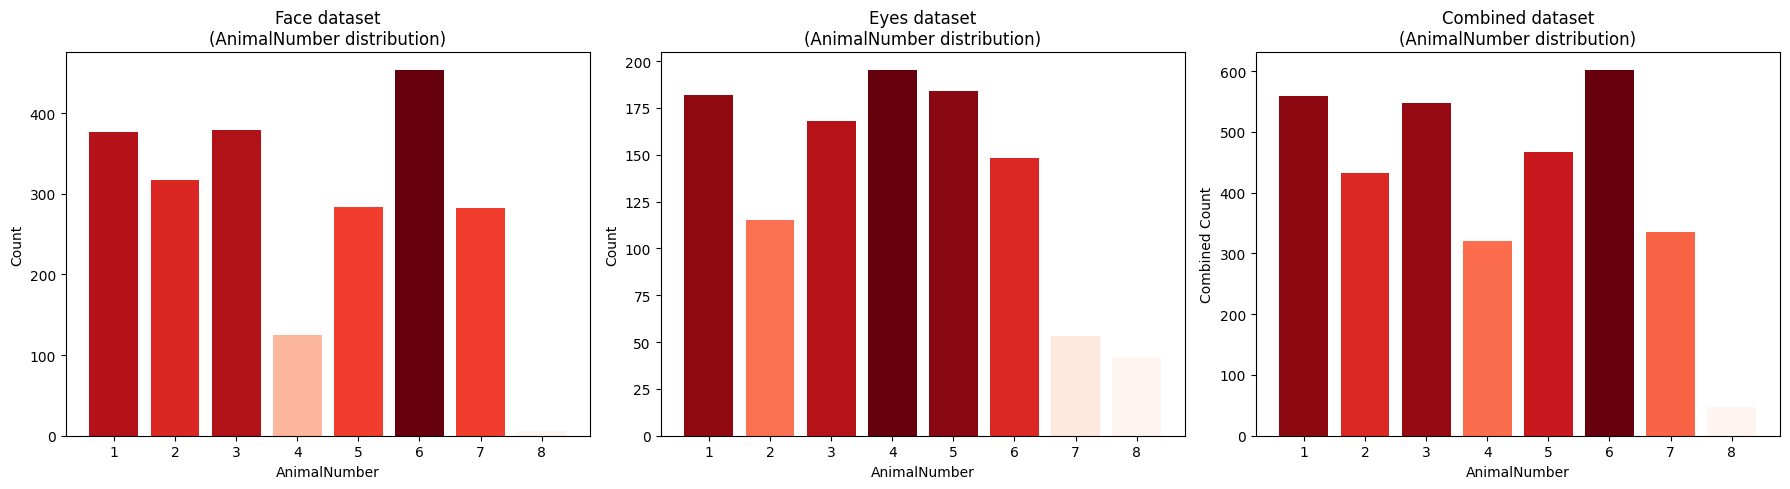

In [ ]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

def get_animal_counts(path):
    """
    Load the JSON file at `path` and count how many times each AnimalNumber appears.
    Returns a pandas Series indexed by AnimalNumber, sorted by index.
    """
    with open(path, "r", encoding="utf-8") as f:
        data = json.load(f)

    records = []
    for image_name, entries in data.items():
        for entry in entries:
            records.append({
                "Image": image_name,
                "AnimalNumber": entry.get("AnimalNumber")
            })

    df = pd.DataFrame(records)
    counts = df["AnimalNumber"].value_counts().sort_index()
    return counts

file_face = "../data/face_detection_data.json"
file_eyes = "../data/eyes_detection_data.json"

counts_face = get_animal_counts(file_face)
counts_eyes = get_animal_counts(file_eyes)

print(f"Face dataset: minimum count = {counts_face.min()}, maximum count = {counts_face.max()}")
print(f"Eyes dataset: minimum count = {counts_eyes.min()}, maximum count = {counts_eyes.max()}")

combined_counts = counts_face.add(counts_eyes, fill_value=0).sort_index()
print(f"Combined dataset: minimum count = {combined_counts.min()}, maximum count = {combined_counts.max()}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5), tight_layout=True)

norm_face = mcolors.Normalize(vmin=counts_face.min(), vmax=counts_face.max())
cmap_face = plt.get_cmap("Reds")
colors_face = [cmap_face(norm_face(v)) for v in counts_face.values]

axes[0].bar(counts_face.index.astype(str), counts_face.values, color=colors_face)
axes[0].set_xlabel("AnimalNumber")
axes[0].set_ylabel("Count")
axes[0].set_title("Face dataset\n(AnimalNumber distribution)")

norm_eyes = mcolors.Normalize(vmin=counts_eyes.min(), vmax=counts_eyes.max())
cmap_eyes = plt.get_cmap("Reds")
colors_eyes = [cmap_eyes(norm_eyes(v)) for v in counts_eyes.values]

axes[1].bar(counts_eyes.index.astype(str), counts_eyes.values, color=colors_eyes)
axes[1].set_xlabel("AnimalNumber")
axes[1].set_ylabel("Count")
axes[1].set_title("Eyes dataset\n(AnimalNumber distribution)")

norm_combined = mcolors.Normalize(vmin=combined_counts.min(), vmax=combined_counts.max())
cmap_combined = plt.get_cmap("Reds")
colors_combined = [cmap_combined(norm_combined(v)) for v in combined_counts.values]

axes[2].bar(combined_counts.index.astype(str), combined_counts.values, color=colors_combined)
axes[2].set_xlabel("AnimalNumber")
axes[2].set_ylabel("Combined Count")
axes[2].set_title("Combined dataset\n(AnimalNumber distribution)")

plt.show()


# Augmentation

Showing eye image augmentation:


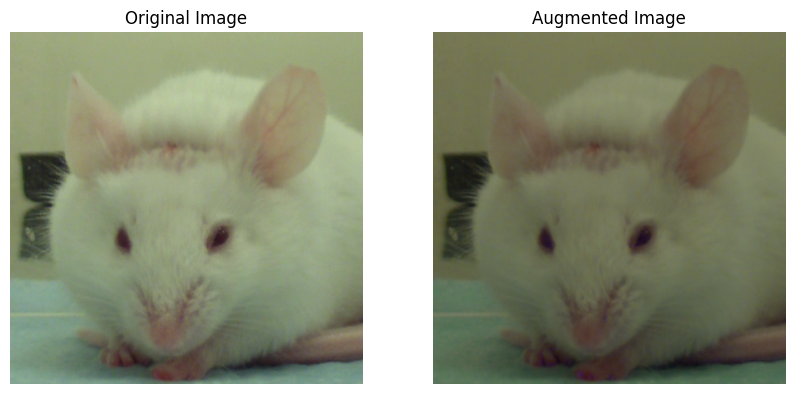


Showing face image augmentation:


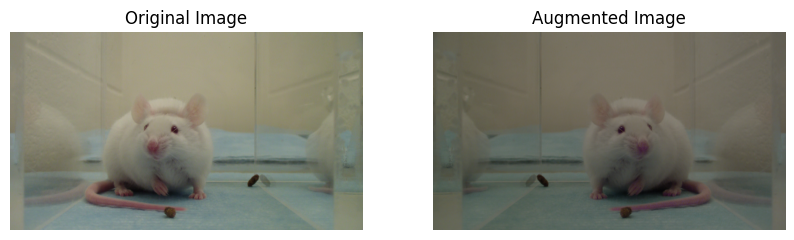

array([[[ 77,  75,  71],
        [ 77,  75,  71],
        [ 77,  75,  72],
        ...,
        [ 98,  93,  73],
        [ 96,  93,  74],
        [ 97,  94,  75]],

       [[ 76,  74,  70],
        [ 76,  74,  70],
        [ 76,  74,  71],
        ...,
        [ 97,  93,  73],
        [ 96,  93,  74],
        [ 96,  93,  74]],

       [[ 75,  80,  62],
        [ 75,  80,  62],
        [ 79,  80,  61],
        ...,
        [ 96,  95,  82],
        [ 96,  96,  79],
        [ 97,  97,  80]],

       ...,

       [[ 92,  91,  88],
        [ 92,  91,  88],
        [ 92,  91,  85],
        ...,
        [100, 102,  88],
        [102,  98,  89],
        [102,  98,  89]],

       [[ 92,  96,  94],
        [ 91,  95,  92],
        [ 93,  97,  87],
        ...,
        [ 98, 102,  86],
        [100, 100,  93],
        [100, 100,  94]],

       [[ 88,  92,  90],
        [ 88,  92,  90],
        [ 90,  94,  84],
        ...,
        [ 98, 102,  86],
        [100, 100,  94],
        [100, 100,  94]]

In [2]:
import cv2
import numpy as np
import os
import matplotlib.pyplot as plt
from random import choice

def augment_image(img_path, show_original=True):
    # Load image
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # Convert to RGB for display
    orig_h, orig_w = img.shape[:2]
    
    if show_original:
        plt.figure(figsize=(10, 5))
        plt.subplot(1, 2, 1)
        plt.imshow(img)
        plt.title('Original Image')
        plt.axis('off')
    
    # Apply augmentations
    # Random horizontal flip
    if np.random.rand() < 0.5:
        img = cv2.flip(img, 1)
    
    # Color jitter (hue, saturation, value)
    jitter = np.random.uniform(0.7, 1.3, 3)
    hsv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV).astype(np.float32)
    hsv[..., 0] = np.clip(hsv[..., 0] * jitter[0], 0, 180)  # Hue
    hsv[..., 1] = np.clip(hsv[..., 1] * jitter[1], 0, 255)  # Saturation
    hsv[..., 2] = np.clip(hsv[..., 2] * jitter[2], 0, 255)  # Value
    img = cv2.cvtColor(hsv.astype(np.uint8), cv2.COLOR_HSV2RGB)
    
    # Random scaling (80% to 120%)
    scale = np.random.uniform(0.8, 1.2)
    new_size = int(orig_w * scale), int(orig_h * scale)
    img = cv2.resize(img, new_size)
    
    # Resize back to original size for display
    img = cv2.resize(img, (orig_w, orig_h))
    
    if show_original:
        plt.subplot(1, 2, 2)
        plt.imshow(img)
        plt.title('Augmented Image')
        plt.axis('off')
        plt.show()
    else:
        plt.figure(figsize=(5, 5))
        plt.imshow(img)
        plt.title('Augmented Image')
        plt.axis('off')
        plt.show()
    
    return img

# Get random image from each folder
eyes_folder = "../Eyes_detection/"
face_folder = "../Face_detection/"

_, _, eyes_files = next(os.walk(eyes_folder))
_, _, face_files = next(os.walk(face_folder))

# Select random images
eye_img = choice(eyes_files)
face_img = choice(face_files)

print("Showing eye image augmentation:")
augment_image(os.path.join(eyes_folder, eye_img))

print("\nShowing face image augmentation:")
augment_image(os.path.join(face_folder, face_img))

In [ ]:
# Load and preprocess image
img = cv2.imread(img_path)
orig_h, orig_w = img.shape[:2]

# Apply augmentations
if self.augment:
    # Random horizontal flip
    if np.random.rand() < 0.5:
        img = cv2.flip(img, 1)
    
    # Color jitter (hue, saturation, value)
    jitter = np.random.uniform(0.7, 1.3, 3)
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV).astype(np.float32)
    hsv[..., 0] = np.clip(hsv[..., 0] * jitter[0], 0, 180)  # Hue
    hsv[..., 1] = np.clip(hsv[..., 1] * jitter[1], 0, 255)  # Saturation
    hsv[..., 2] = np.clip(hsv[..., 2] * jitter[2], 0, 255)  # Value
    img = cv2.cvtColor(hsv.astype(np.uint8), cv2.COLOR_HSV2BGR)
    
    # Random scaling (80% to 120%)
    scale = np.random.uniform(0.8, 1.2)
    new_size = int(orig_w * scale), int(orig_h * scale)
    img = cv2.resize(img, new_size)

img = cv2.resize(img, (self.img_size, self.img_size))
img = torch.tensor(img, dtype=torch.float32).permute(2, 0, 1) / 255.0

# Initialize target tensor
target = torch.zeros((self.max_objects, 5), dtype=torch.float32) - 1

if os.path.exists(label_path):
    with open(label_path, 'r') as f:
        lines = f.readlines()
        for i, line in enumerate(lines):
            if i >= self.max_objects:
                break
                
            class_id, x_center, y_center, width, height = map(float, line.strip().split())
            target[i] = torch.tensor([x_center, y_center, width, height, class_id])

if self.cache_images:
    self.cache[idx] = (img, target)
    
return img, target